In [ ]:
# ==========================================
# 1. IMPORTAR LIBRERÍAS
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [ ]:
# ==========================================
# 2. CARGAR EL DATASET
# ==========================================

# Descargar y cargar el conjunto de rostros
faces_data = fetch_olivetti_faces()

# Matriz de imágenes aplanadas: 400 x 4096
X = faces_data.data

# Etiquetas de identidad: valores de 0 a 39
y = faces_data.target

# Imágenes originales de 64 x 64
images = faces_data.images

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
print("Número de personas:", len(np.unique(y)))
print("Total de imágenes:", len(images))

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Dimensiones de X: (400, 4096)
Dimensiones de y: (400,)
Número de personas: 40
Total de imágenes: 400


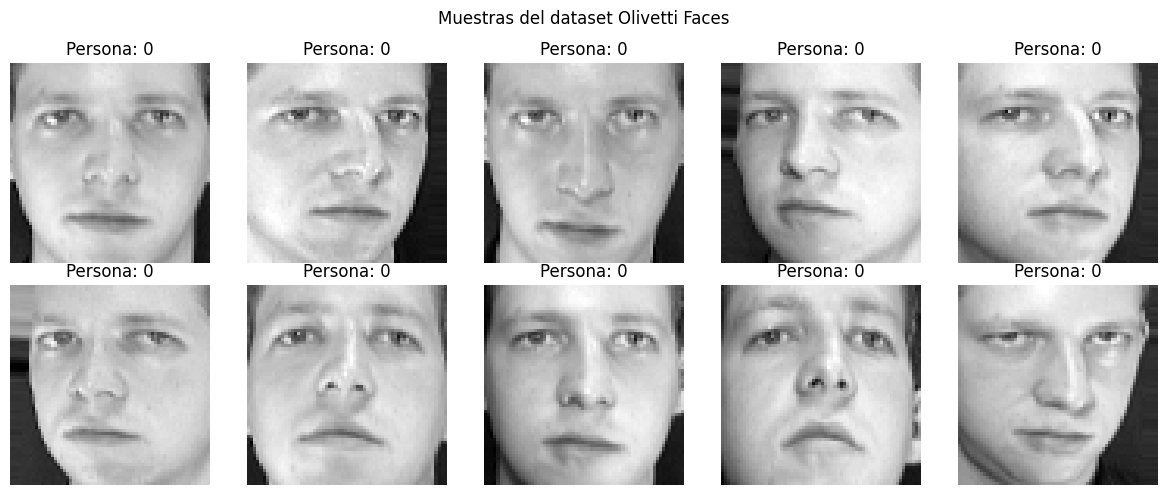

In [ ]:
# ==========================================
# 3. VISUALIZAR ROSTROS DEL DATASET
# ==========================================

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(images[i], cmap="gray")
    plt.title(f"Persona: {y[i]}")
    plt.axis("off")

plt.suptitle("Muestras del dataset Olivetti Faces")
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 4. DIVIDIR LOS DATOS
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Imágenes de entrenamiento:", X_train.shape[0])
print("Imágenes de prueba:", X_test.shape[0])

Imágenes de entrenamiento: 300
Imágenes de prueba: 100


In [ ]:
# ==========================================
# 5. CREAR EL MODELO EIGENFACES + SVM
# ==========================================

# Crear un pipeline con PCA y SVM
modelo = Pipeline([
    # PCA extrae 150 características principales
    ("pca", PCA(
        n_components=150,
        whiten=True,
        svd_solver="randomized",
        random_state=42
    )),

    # SVM reconoce la identidad del rostro
    ("svm", SVC(
        kernel="rbf",
        C=10,
        gamma="scale"
    ))
])

# Entrenar el sistema
modelo.fit(X_train, y_train)

print("¡Modelo Eigenfaces entrenado correctamente!")

¡Modelo Eigenfaces entrenado correctamente!


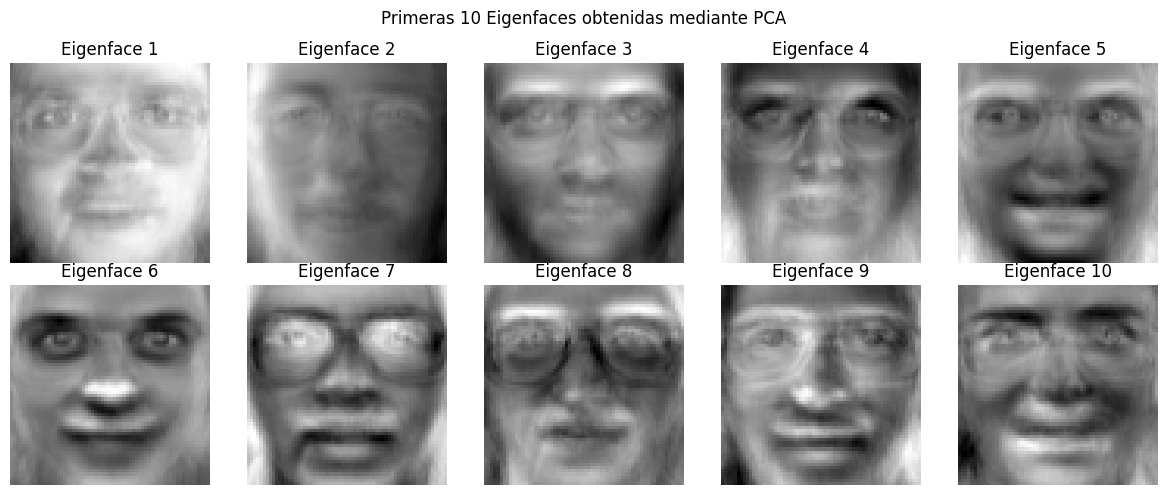

Varianza explicada por PCA: 97.25%


In [ ]:
# ==========================================
# 6. VISUALIZAR LAS EIGENFACES
# ==========================================

# Obtener el PCA ya entrenado dentro del pipeline
pca = modelo.named_steps["pca"]

# Mostrar las primeras 10 Eigenfaces
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    eigenface = pca.components_[i].reshape(64, 64)

    plt.imshow(eigenface, cmap="gray")
    plt.title(f"Eigenface {i + 1}")
    plt.axis("off")

plt.suptitle("Primeras 10 Eigenfaces obtenidas mediante PCA")
plt.tight_layout()
plt.show()

# Mostrar cuánta varianza explican los 150 componentes
varianza = np.sum(pca.explained_variance_ratio_)

print(f"Varianza explicada por PCA: {varianza:.2%}")

In [ ]:
# ==========================================
# 7. EVALUAR EL MODELO
# ==========================================

# Predecir las identidades de las imágenes de prueba
y_pred = modelo.predict(X_test)

# Calcular exactitud
accuracy = accuracy_score(y_test, y_pred)

print(f"Exactitud del modelo: {accuracy:.2%}")

# Mostrar métricas por persona
print("\nReporte de clasificación:")
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

Exactitud del modelo: 98.00%

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.67      0.80         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          16       1.00  

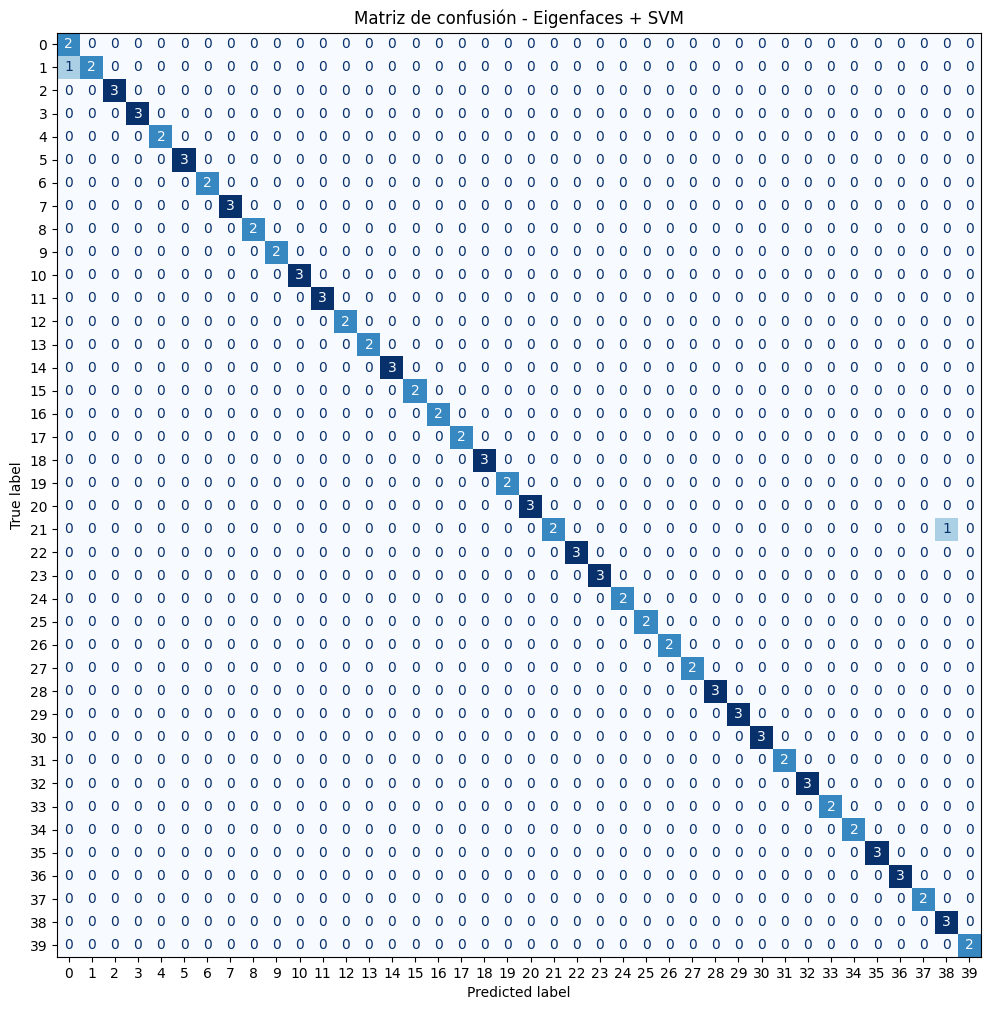

In [ ]:
# ==========================================
# 8. MATRIZ DE CONFUSIÓN
# ==========================================

fig, ax = plt.subplots(figsize=(12, 12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Matriz de confusión - Eigenfaces + SVM")
plt.show()

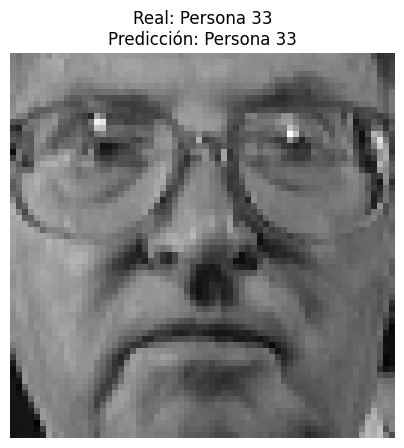

¡Rostro reconocido correctamente!


In [ ]:
# ==========================================
# 9. PROBAR EL RECONOCIMIENTO FACIAL
# ==========================================

# Seleccionar una imagen del conjunto de prueba
indice = 8

rostro = X_test[indice].reshape(1, -1)

# Predecir la identidad
prediccion = modelo.predict(rostro)[0]

# Obtener identidad real
identidad_real = y_test[indice]

# Mostrar el rostro
plt.figure(figsize=(5, 5))

plt.imshow(X_test[indice].reshape(64, 64), cmap="gray")

plt.title(
    f"Real: Persona {identidad_real}\n"
    f"Predicción: Persona {prediccion}"
)

plt.axis("off")
plt.show()

# Mostrar resultado
if prediccion == identidad_real:
    print("¡Rostro reconocido correctamente!")
else:
    print("El modelo confundió la identidad.")


b. recomendar artículos similares al artículo que está leyendo actualmente un cliente.


In [ ]:
# ==========================================
# 1. INSTALAR E IMPORTAR LIBRERÍAS
# ==========================================

# Instalamos la librería para trabajar con embeddings
!pip install -q sentence-transformers

# Librerías
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print("Librerías instaladas e importadas correctamente")

Librerías instaladas e importadas correctamente


In [ ]:
# ==========================================
# 2. CARGAR EL DATASET AG NEWS
# ==========================================

from datasets import load_dataset

# Descargar el dataset
dataset = load_dataset("fancyzhx/ag_news")

# Convertir entrenamiento y prueba a DataFrames
df_train = pd.DataFrame(dataset["train"])
df_test = pd.DataFrame(dataset["test"])

# Unir ambos conjuntos para tener una colección
# completa de artículos para recomendar
df = pd.concat([df_train, df_test], ignore_index=True)

# Mostrar información básica
print("Total de artículos:", len(df))
print("Columnas:", df.columns.tolist())

print("\nPrimeros artículos:")
display(df.head())

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Total de artículos: 127600
Columnas: ['text', 'label']

Primeros artículos:


,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [ ]:
# ==========================================
# 3. CONVERTIR LAS ETIQUETAS A CATEGORÍAS
# ==========================================

# Diccionario de categorías
categorias = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

# Crear una nueva columna con el nombre de la categoría
df["categoria"] = df["label"].map(categorias)

# Mostrar algunos artículos
display(df[["text", "categoria"]].head())

# Mostrar cantidad de artículos por categoría
print("\nCantidad de artículos por categoría:")
print(df["categoria"].value_counts())

,text,categoria
0,Wall St. Bears Claw Back Into the Black (Reute...,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,Business
4,"Oil prices soar to all-time record, posing new...",Business



Cantidad de artículos por categoría:
categoria
Business    31900
Sci/Tech    31900
Sports      31900
World       31900
Name: count, dtype: int64


In [ ]:
# ==========================================
# 4. CARGAR EL MODELO DE EMBEDDINGS
# ==========================================

# Cargar modelo preentrenado
modelo_embedding = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("Modelo de embeddings cargado correctamente")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo de embeddings cargado correctamente


In [ ]:
# ==========================================
# 5. GENERAR EMBEDDINGS DE LOS ARTÍCULOS
# ==========================================

# Cantidad de artículos que utilizaremos
N_ARTICULOS = 10000

# Tomamos una muestra reproducible
df_recomendador = df.sample(
    n=N_ARTICULOS,
    random_state=42
).reset_index(drop=True)

print("Artículos seleccionados:", len(df_recomendador))

# Obtener los textos
textos = df_recomendador["text"].tolist()

# Generar embeddings
embeddings = modelo_embedding.encode(
    textos,
    show_progress_bar=True,
    batch_size=32,
    normalize_embeddings=True
)

print("\nEmbeddings generados correctamente")
print("Dimensiones de los embeddings:", embeddings.shape)

Artículos seleccionados: 10000


Batches:   0%|          | 0/313 [00:00<?, ?it/s]


Embeddings generados correctamente
Dimensiones de los embeddings: (10000, 384)


In [ ]:
# ==========================================
# 6. FUNCIÓN DE RECOMENDACIÓN
# ==========================================

def recomendar_articulos(indice_articulo, top_n=5):

    # Obtener el embedding del artículo seleccionado
    embedding_articulo = embeddings[indice_articulo].reshape(1, -1)

    # Calcular similitud entre el artículo seleccionado
    # y todos los artículos de nuestra colección
    similitudes = cosine_similarity(
        embedding_articulo,
        embeddings
    ).flatten()

    # Ordenar los artículos de mayor a menor similitud
    indices_ordenados = np.argsort(similitudes)[::-1]

    # Eliminar el propio artículo de las recomendaciones
    indices_ordenados = [
        i for i in indices_ordenados
        if i != indice_articulo
    ]

    # Seleccionar los artículos más similares
    mejores_indices = indices_ordenados[:top_n]

    # Crear tabla con las recomendaciones
    recomendaciones = df_recomendador.iloc[
        mejores_indices
    ][["text", "categoria"]].copy()

    # Agregar el porcentaje de similitud
    recomendaciones["similitud"] = [
        similitudes[i]
        for i in mejores_indices
    ]

    return recomendaciones

In [ ]:
# ==========================================
# 7. PROBAR EL SISTEMA DE RECOMENDACIÓN
# ==========================================

# Seleccionar un artículo
indice_articulo = 100

# Mostrar el artículo seleccionado
print("=" * 80)
print("ARTÍCULO QUE ESTÁ LEYENDO EL USUARIO")
print("=" * 80)

print("\nCategoría:", df_recomendador.loc[indice_articulo, "categoria"])
print("\nArtículo:")
print(df_recomendador.loc[indice_articulo, "text"])

# Obtener 5 artículos similares
recomendaciones = recomendar_articulos(
    indice_articulo,
    top_n=5
)

# Mostrar recomendaciones
print("\n\n" + "=" * 80)
print("ARTÍCULOS RECOMENDADOS")
print("=" * 80)

for i, (_, articulo) in enumerate(
    recomendaciones.iterrows(),
    start=1
):

    print(f"\nRECOMENDACIÓN {i}")
    print("-" * 80)

    print("Categoría:", articulo["categoria"])
    print(f"Similitud: {articulo['similitud']:.4f}")

    print("\nArtículo:")
    print(articulo["text"])

ARTÍCULO QUE ESTÁ LEYENDO EL USUARIO

Categoría: Sports

Artículo:
Coach Sam raises bar Head coach Sam Mitchell has set some substantial goals for Carter, the club #39;s best swingman, and Bosh, the club #39;s best big man.


ARTÍCULOS RECOMENDADOS

RECOMENDACIÓN 1
--------------------------------------------------------------------------------
Categoría: Sports
Similitud: 0.4256

Artículo:
Nets: A STAR RISES, FADES IN CANADA Vince Carter had everything a basketball player could want: A fat contract, highlight-reel talent and an entire nation that had anointed him as its favorite athlete not on ice skates.

RECOMENDACIÓN 2
--------------------------------------------------------------------------------
Categoría: Sports
Similitud: 0.4174

Artículo:
Ward still standing for US Score tied. One round to go. A shot at an Olympic boxing gold medal at stake. Apparently only US coach Basheer Abdullah didn #39;t know his 178-pound fighter, Andre Ward, was even with 

RECOMENDACIÓN 3
-----------

In [ ]:
# ==========================================
# 8. PROBAR DIFERENTES ARTÍCULOS
# ==========================================

# Artículos que queremos probar
indices_prueba = [100, 500, 1000]

for indice in indices_prueba:

    print("\n" + "=" * 80)
    print(f"ARTÍCULO ORIGINAL - ID: {indice}")
    print("=" * 80)

    print("Categoría:", df_recomendador.loc[indice, "categoria"])
    print("\nTexto:")
    print(df_recomendador.loc[indice, "text"][:500])

    # Obtener recomendaciones
    recomendaciones = recomendar_articulos(
        indice,
        top_n=3
    )

    print("\n--- RECOMENDACIONES ---")

    for i, (_, articulo) in enumerate(
        recomendaciones.iterrows(),
        start=1
    ):
        print(f"\n{i}. Categoría: {articulo['categoria']}")
        print(f"   Similitud: {articulo['similitud']:.4f}")
        print(f"   {articulo['text'][:300]}...")


ARTÍCULO ORIGINAL - ID: 100
Categoría: Sports

Texto:
Coach Sam raises bar Head coach Sam Mitchell has set some substantial goals for Carter, the club #39;s best swingman, and Bosh, the club #39;s best big man.

--- RECOMENDACIONES ---

1. Categoría: Sports
   Similitud: 0.4256
   Nets: A STAR RISES, FADES IN CANADA Vince Carter had everything a basketball player could want: A fat contract, highlight-reel talent and an entire nation that had anointed him as its favorite athlete not on ice skates....

2. Categoría: Sports
   Similitud: 0.4174
   Ward still standing for US Score tied. One round to go. A shot at an Olympic boxing gold medal at stake. Apparently only US coach Basheer Abdullah didn #39;t know his 178-pound fighter, Andre Ward, was even with ...

3. Categoría: Sports
   Similitud: 0.4010
   Carter #39;s  #39;got nothing to say #39; after scoring 15 After hearing rare boos from the home fans, Vince Carter didn #39;t want to talk about it. Carter had 15 points in his first ga

In [ ]:
# ==========================================
# 9. RECOMENDAR ARTÍCULOS PARA UN TEXTO NUEVO
# ==========================================

def recomendar_por_texto(texto, top_n=5):

    # Convertir el nuevo artículo en un embedding
    embedding_nuevo = modelo_embedding.encode(
        [texto],
        normalize_embeddings=True
    )

    # Comparar el nuevo artículo con todos los existentes
    similitudes = cosine_similarity(
        embedding_nuevo,
        embeddings
    ).flatten()

    # Obtener los índices de mayor similitud
    mejores_indices = np.argsort(similitudes)[::-1][:top_n]

    # Crear tabla de resultados
    resultados = df_recomendador.iloc[
        mejores_indices
    ][["text", "categoria"]].copy()

    resultados["similitud"] = [
        similitudes[i]
        for i in mejores_indices
    ]

    return resultados


# ------------------------------------------
# ARTÍCULO NUEVO
# ------------------------------------------

articulo_nuevo = """
Technology companies are developing new artificial
intelligence systems that can improve productivity,
automate tasks and transform the way businesses
use software and digital services.
"""

# Obtener recomendaciones
recomendaciones_nuevas = recomendar_por_texto(
    articulo_nuevo,
    top_n=5
)

# Mostrar resultados
print("=" * 80)
print("ARTÍCULO NUEVO")
print("=" * 80)
print(articulo_nuevo)

print("\n" + "=" * 80)
print("ARTÍCULOS RECOMENDADOS")
print("=" * 80)

for i, (_, articulo) in enumerate(
    recomendaciones_nuevas.iterrows(),
    start=1
):

    print(f"\nRECOMENDACIÓN {i}")
    print("-" * 80)
    print("Categoría:", articulo["categoria"])
    print(f"Similitud: {articulo['similitud']:.4f}")
    print("\nArtículo:")
    print(articulo["text"][:500])

ARTÍCULO NUEVO

Technology companies are developing new artificial
intelligence systems that can improve productivity,
automate tasks and transform the way businesses
use software and digital services.


ARTÍCULOS RECOMENDADOS

RECOMENDACIÓN 1
--------------------------------------------------------------------------------
Categoría: Sci/Tech
Similitud: 0.4935

Artículo:
IDC Forum: Is IT creativity dead? Pouring fuel on the debate over whether IT provides a competitive advantage to corporations, a pair of prominent industry observers Monday offered starkly different views of the role computer technology can play in transforming business strategy.

RECOMENDACIÓN 2
--------------------------------------------------------------------------------
Categoría: Sci/Tech
Similitud: 0.4889

Artículo:
Indian tech firms face skills gap India's IT research and outsourcing  industry is facing a skills shortage, a leading industry expert has warned.

RECOMENDACIÓN 3
----------------------------------

Entrene un modelo ensemble para detectar anomalías en series temporales.


In [73]:
# ============================================
# CELDA 1: LIBRERÍAS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import NearestNeighbors
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

In [74]:
# ============================================
# CELDA 2: CARGAR DATASET
# ============================================

url = "https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/machine_temperature_system_failure.csv"

df = pd.read_csv(url)

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp").reset_index(drop=True)

print("Filas:", len(df))
print("Columnas:", df.columns.tolist())

display(df.head())

Filas: 22695
Columnas: ['timestamp', 'value']


,timestamp,value
0,2013-12-02 21:15:00,73.967322
1,2013-12-02 21:20:00,74.935882
2,2013-12-02 21:25:00,76.124162
3,2013-12-02 21:30:00,78.140707
4,2013-12-02 21:35:00,79.329836


In [75]:
# ============================================
# CELDA 3: REVISAR TEMPERATURA
# ============================================

print("Temperatura mínima:", df["value"].min())
print("Temperatura máxima:", df["value"].max())
print("Temperatura promedio:", df["value"].mean())
print("Desviación estándar:", df["value"].std())

print("\nPercentiles:")
print(df["value"].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]))

Temperatura mínima: 2.084721206
Temperatura máxima: 108.5105428
Temperatura promedio: 85.92649821068021
Desviación estándar: 13.746912473090113

Percentiles:
0.01     32.535952
0.05     55.615308
0.25     83.080078
0.50     89.408246
0.75     94.016252
0.95    100.850769
0.99    102.978814
Name: value, dtype: float64


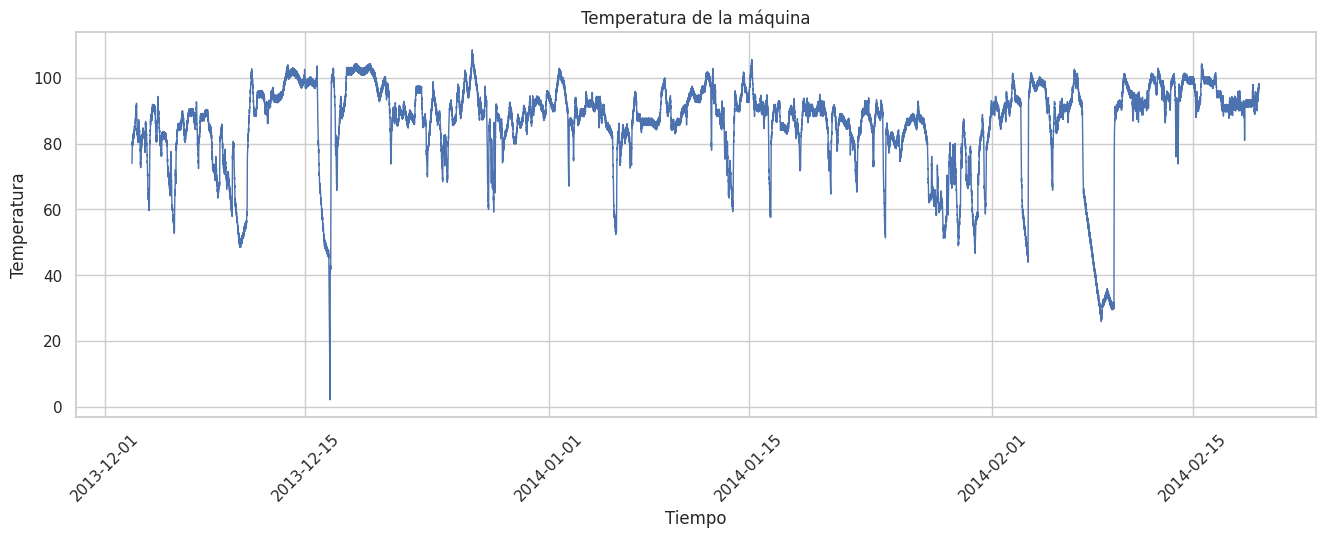

In [76]:
# ============================================
# CELDA 4: SERIE TEMPORAL
# ============================================

plt.figure(figsize=(16, 5))

plt.plot(
    df["timestamp"],
    df["value"],
    linewidth=1
)

plt.title("Temperatura de la máquina")
plt.xlabel("Tiempo")
plt.ylabel("Temperatura")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [77]:
# ============================================
# CELDA 5: PREPARAR DATOS
# ============================================

X = df[["value"]].copy()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Datos preparados:", X_scaled.shape)

Datos preparados: (22695, 1)


In [78]:
# ============================================
# CELDA 6: ISOLATION FOREST
# ============================================

model_if = IsolationForest(
    n_estimators=300,
    contamination=0.005,
    random_state=42
)

model_if.fit(X_scaled)

pred_if = model_if.predict(X_scaled)

# -1 = anomalía
#  1 = normal

df["IF_anomalia"] = (
    pred_if == -1
).astype(int)

print(
    "Anomalías detectadas:",
    df["IF_anomalia"].sum()
)

Anomalías detectadas: 111


In [79]:
# ============================================
# CELDA 7: KNN
# ============================================

knn = NearestNeighbors(
    n_neighbors=10
)

knn.fit(X_scaled)

distancias, indices = knn.kneighbors(X_scaled)

# Distancia al vecino más alejado
# dentro de los 10 vecinos

df["distancia_knn"] = distancias[:, -1]

print(
    df["distancia_knn"].describe()
)

count    22695.000000
mean         0.001568
std          0.015741
min          0.000073
25%          0.000273
50%          0.000423
75%          0.000823
max          1.045522
Name: distancia_knn, dtype: float64


In [80]:
# ============================================
# CELDA 8: ANOMALÍAS KNN
# ============================================

# Solo consideramos como anomalías
# el 0.5% de los puntos más alejados

umbral_knn = np.percentile(
    df["distancia_knn"],
    99.5
)

df["KNN_anomalia"] = (
    df["distancia_knn"] > umbral_knn
).astype(int)

print("Umbral KNN:", umbral_knn)

print(
    "Anomalías detectadas:",
    df["KNN_anomalia"].sum()
)

Umbral KNN: 0.02489226989544001
Anomalías detectadas: 114


In [87]:
# ============================================
# CELDA 9: ONE-CLASS SVM
# ============================================

model_svm = OneClassSVM(
    kernel="rbf",
    gamma=0.01,
    nu=0.001
)

model_svm.fit(X_scaled)

pred_svm = model_svm.predict(X_scaled)

# -1 = anomalía
#  1 = normal

df["SVM_anomalia"] = (
    pred_svm == -1
).astype(int)

print(
    "Anomalías detectadas:",
    df["SVM_anomalia"].sum()
)

Anomalías detectadas: 24


In [88]:
# ============================================
# CELDA 10: COMPARACIÓN DE MODELOS
# ============================================

print("RESULTADOS")
print("=" * 50)

print(
    "Isolation Forest:",
    df["IF_anomalia"].sum()
)

print(
    "KNN:",
    df["KNN_anomalia"].sum()
)

print(
    "One-Class SVM:",
    df["SVM_anomalia"].sum()
)

RESULTADOS
Isolation Forest: 111
KNN: 114
One-Class SVM: 24


In [89]:
# ============================================
# CELDA 11: ENSEMBLE
# ============================================

df["votos_anomalia"] = (
    df["IF_anomalia"] +
    df["KNN_anomalia"] +
    df["SVM_anomalia"]
)

# Una observación será anomalía
# cuando al menos 2 modelos coincidan

df["ENSEMBLE_anomalia"] = (
    df["votos_anomalia"] >= 2
).astype(int)

print(
    "Anomalías detectadas por Ensemble:",
    df["ENSEMBLE_anomalia"].sum()
)

Anomalías detectadas por Ensemble: 48


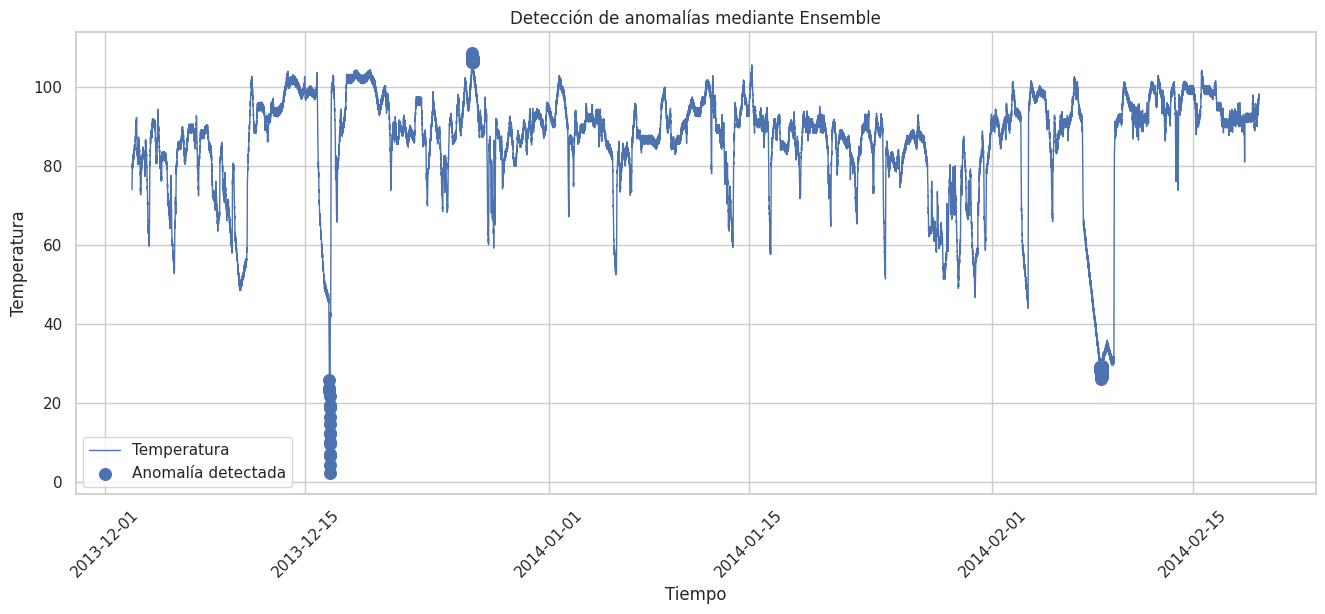

In [90]:
# ============================================
# CELDA 12: RESULTADO FINAL
# ============================================

plt.figure(figsize=(16, 6))

# Serie completa
plt.plot(
    df["timestamp"],
    df["value"],
    linewidth=1,
    label="Temperatura"
)

# Anomalías del ensemble
anomalias = df[
    df["ENSEMBLE_anomalia"] == 1
]

plt.scatter(
    anomalias["timestamp"],
    anomalias["value"],
    s=70,
    label="Anomalía detectada"
)

plt.title(
    "Detección de anomalías mediante Ensemble"
)

plt.xlabel("Tiempo")
plt.ylabel("Temperatura")

plt.legend()

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [91]:
# ============================================
# CELDA 13: TABLA DE ANOMALÍAS
# ============================================

anomalias_finales = df[
    df["ENSEMBLE_anomalia"] == 1
][
    [
        "timestamp",
        "value",
        "IF_anomalia",
        "KNN_anomalia",
        "SVM_anomalia",
        "votos_anomalia"
    ]
]

display(anomalias_finales)

,timestamp,value,IF_anomalia,KNN_anomalia,SVM_anomalia,votos_anomalia
3972,2013-12-16 16:15:00,25.680672,1,1,0,2
3973,2013-12-16 16:20:00,23.829044,1,1,0,2
3974,2013-12-16 16:25:00,22.983839,1,1,0,2
3975,2013-12-16 16:30:00,21.737032,1,1,0,2
3976,2013-12-16 16:35:00,19.277179,1,1,0,2
3977,2013-12-16 16:40:00,18.591971,1,1,1,3
3978,2013-12-16 16:45:00,16.457109,1,1,1,3
3979,2013-12-16 16:50:00,14.671060,1,1,1,3
3980,2013-12-16 16:55:00,12.414093,1,1,1,3
3981,2013-12-16 17:00:00,9.633952,1,1,1,3


In [86]:
# ============================================
# CELDA 14: GUARDAR RESULTADOS
# ============================================

df_resultado = df[
    [
        "timestamp",
        "value",
        "IF_anomalia",
        "KNN_anomalia",
        "SVM_anomalia",
        "votos_anomalia",
        "ENSEMBLE_anomalia"
    ]
]

df_resultado.to_csv(
    "resultado_ensemble_anomalias.csv",
    index=False
)

print("Archivo creado correctamente.")

Archivo creado correctamente.


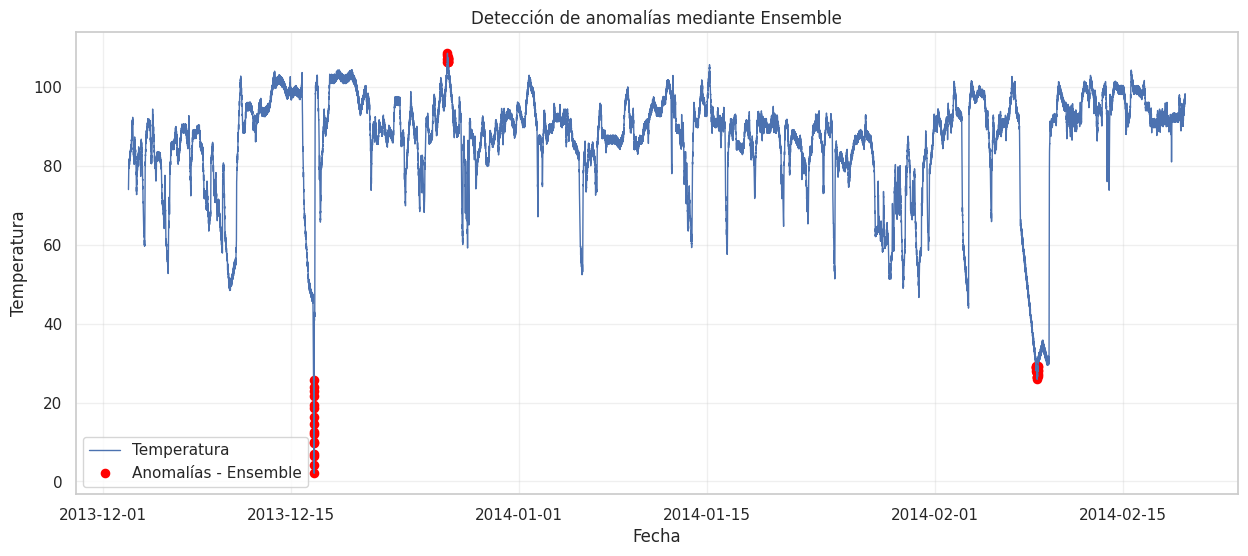

In [92]:
# ============================================
# GRÁFICO FINAL DEL ENSEMBLE
# ============================================

plt.figure(figsize=(15, 6))

# Serie temporal completa
plt.plot(
    df["timestamp"],
    df["value"],
    label="Temperatura",
    linewidth=1
)

# Anomalías detectadas por el ensemble
anomalias = df[df["ENSEMBLE_anomalia"] == 1]

plt.scatter(
    anomalias["timestamp"],
    anomalias["value"],
    color="red",
    s=35,
    label="Anomalías - Ensemble"
)

plt.title("Detección de anomalías mediante Ensemble")
plt.xlabel("Fecha")
plt.ylabel("Temperatura")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()